# 读取APS数据文件, 绘制时间序列图

version: 1.0

## 处理单个数据文件

注意: 在读取函数写出来后处于废弃状态

In [ ]:
# 处理单个APS导出的数据文件，读取并打印自检信息(在读取函数写出来后处于废弃状态)
import numpy as np
import pandas as pd
import pathlib

file_path = pathlib.Path(r"D:\Coding\Data\Lanzhou_aerosol\APS_dNdlogDp\20241206.TXT")

# 1) 读取txt文件
df = pd.read_csv(file_path, sep="\t", encoding="cp1252", skiprows=6)

# 2) 日期列、时间列 #print(df.columns) #查看列名
date_col = 'Date'
time_col = 'Start Time'

# 3) 合并成 datetime 并排序
t = pd.to_datetime(df[date_col]+' '+df[time_col], format='%m/%d/%y %H:%M:%S')
df["__dt__"] = t
df = df.sort_values("__dt__").reset_index(drop=True)
t = df["__dt__"]

# 4) 粒径bin列 #print(df.columns) #查看列名
bin_cols = [
    '<0.523', '0.542', '0.583', '0.626', '0.673', '0.723', '0.777', '0.835', '0.898',
       '0.965', '1.037', '1.114', '1.197', '1.286', '1.382', '1.486', '1.596',
       '1.715', '1.843', '1.981', '2.129', '2.288', '2.458', '2.642', '2.839',
       '3.051', '3.278', '3.523', '3.786', '4.068', '4.371', '4.698', '5.048',
       '5.425', '5.829', '6.264', '6.732', '7.234', '7.774', '8.354', '8.977',
       '9.647', '10.37', '11.14', '11.97', '12.86', '13.82', '14.86', '15.96',
       '17.15', '18.43', '19.81'
       ]
Dp = np.array([
    0.523, 0.542, 0.583, 0.626, 0.673, 0.723, 0.777, 0.835, 0.898,
    0.965, 1.037, 1.114, 1.197, 1.286, 1.382, 1.486, 1.596,
    1.715, 1.843, 1.981, 2.129, 2.288, 2.458, 2.642, 2.839,
    3.051, 3.278, 3.523, 3.786, 4.068, 4.371, 4.698, 5.048,
    5.425, 5.829, 6.264, 6.732, 7.234, 7.774, 8.354, 8.977,
    9.647, 10.37, 11.14, 11.97, 12.86, 13.82, 14.86, 15.96,
    17.15, 18.43, 19.81
], dtype=float)

# 6) 取出矩阵 dN.shape == （bin × time）
dN = df[bin_cols].apply(pd.to_numeric).to_numpy().T

# 7) 打印自检信息
dt_diff = pd.Series(t).diff().dropna() # 计算时间间隔
print("时间点数 =", len(t))
print("粒径bin数 =", len(Dp))
print("Dp范围(µm) =", np.nanmin(Dp), "~", np.nanmax(Dp))
print("采样间隔(秒)：中位数 =", dt_diff.dt.total_seconds().median(),
      "，最小 =", dt_diff.dt.total_seconds().min(),
      "，最大 =", dt_diff.dt.total_seconds().max())
print("dN/dlogDp统计(#/cm3)：min =", np.nanmin(dN), "max =", np.nanmax(dN))
print("dN/dlogDp为0或缺测的比例 =", np.mean((dN <= 0) | np.isnan(dN)))
print("log10(dN/dlogDp)最大值（忽略<=0）≈", np.nanmax(np.log10(np.where(dN>0, dN, np.nan))))

In [ ]:
df.columns
df['19.81']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from matplotlib.ticker import FixedLocator, NullFormatter

# --- 0) 准备：确保 t 是 datetime，Dp 是 float array，dN 是 (bin, time) ---
# t: pandas Series of datetime
# Dp: numpy array (len=bin)
# dN: numpy array shape = (bin, time)

# 1) 计算 x 轴边界（pcolormesh 需要 edges）
t_num = mdates.date2num(pd.to_datetime(t).to_numpy())
dt = np.median(np.diff(t_num))
x_edges = np.r_[t_num[0] - 0.5*dt,
                0.5*(t_num[:-1] + t_num[1:]),
                t_num[-1] + 0.5*dt]

# 2) 计算 y 轴边界（用相邻几何均值当 bin 边界；首尾做外推）
y_edges = np.empty(len(Dp)+1)
y_edges[1:-1] = np.sqrt(Dp[:-1] * Dp[1:])
y_edges[0] = Dp[0]**2 / y_edges[1]
y_edges[-1] = Dp[-1]**2 / y_edges[-2]

# 3) 颜色：log10(dN)，<=0 设为 NaN（否则 log 会报错）
Z = np.log10(np.where(dN > 0, dN, np.nan))

# 4) 作图
fig, ax = plt.subplots(figsize=(12, 2.6), dpi=160)

pcm = ax.pcolormesh(
    x_edges, y_edges, Z,
    shading="auto",
    cmap="jet",
    vmin=0, vmax=2.5
)

ax.set_yscale("log")
ax.set_ylabel("Aerodynamic diameter (µm)")
ax.set_xlabel("Date")
# y 刻度
yticks = [0.6, 1, 2, 4, 6, 10]
ax.yaxis.set_major_locator(FixedLocator(yticks))
ax.yaxis.set_major_formatter(lambda v, pos: f"{v:g}")
ax.set_ylim(y_edges[0], y_edges[-1])

# x 轴按天显示
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
fig.autofmt_xdate()# 自动旋转日期标签

# colorbar
cbar = fig.colorbar(pcm, ax=ax, pad=0.01)
cbar.set_label("APS dN (cm$^{-3}$)  (log$_{10}$)", rotation=270, labelpad=15)
cbar.set_ticks([0, 0.5, 1, 1.5, 2, 2.5])

plt.tight_layout()
plt.show()


## 处理多个数据文件

In [1]:
# 1. 导入库, 定义读取函数
from pathlib import Path
import pandas as pd
import numpy as np

def read_one_aps_export(path: Path, encoding="cp1252", bin_start_idx=4, bin_end_idx=56, time_format="%m/%d/%y %H:%M:%S", scan_lines=100) -> pd.DataFrame:
    '''
    读取单个 APS 导出 TXT 文件，返回包含时间和粒径列的 DataFrame。
    参数:
    '''
    # 1) 定位表头行 (只扫描前`scan_lines`行)s
    with open(path, "r", encoding=encoding, errors="replace") as f:
        lines = []
        for _ in range(scan_lines):
            try:
                lines.append(next(f))
            except StopIteration:
                break

    header_idx = None
    for i, line in enumerate(lines):
        if "Sample #" in line and "Date" in line and "Start Time" in line:
            if line.count("\t") >= 5 or line.count(",") >= 5 or line.count(";") >= 5:
                header_idx = i
                break
    if header_idx is None:
        raise ValueError(f"{path.name}: 扫描前`scan_lines`({scan_lines})行, 未找到表头行")

    header_line = lines[header_idx]

    # 2) 识别分隔符
    delims = {"\t": header_line.count("\t"), ",": header_line.count(","), ";": header_line.count(";")}
    sep = max(delims, key=delims.get)

    # 3) 从表头行开始读
    df = pd.read_csv(path, sep=sep, encoding=encoding, skiprows=header_idx, header=0, engine="python")
    #print(f"`{path.name}`的数据类型: {df.iloc[0, 3]}")
    if df.iloc[0, 3] != "dN/dlogDp":
        raise ValueError(f"{path.name}: 数据类型不是 dN/dlogDp，而是 {df.iloc[0, 3]}")
    # 4) 生成 datetime
    t = pd.to_datetime(df["Date"].astype(str).str.strip() + " " + df["Start Time"].astype(str).str.strip(),
                       errors="coerce", # 如果需要更严格的解析, 可以去掉此行
                       format=time_format)
    bad = t.isna()
    if bad.any():
        print("解析失败行数:", bad.sum())
        print("如果行数较多，可能需要调整 time_format 参数")
        print(df.loc[bad, ["Date", "Start Time"]].head(10))
        # 需要的话：raise ValueError("Datetime parsing failed")
    
    df = df.loc[t.notna()].copy()
    df["__dt__"] = t.loc[t.notna()].values

    # 5) 粒径列 
    # 目前计划用全局变量控制，没想到其他好的办法
    #BIN_COLS = list(df.columns[bin_start_idx:bin_end_idx])
    # 判断粒径列是否正确选取
    #try:
    #    _ = np.array(BIN_COLS).astype(float)
    #except ValueError:
    #    raise ValueError(f"{path.name}: 粒径列名不能转换为浮点数，可能选取错误：{BIN_COLS[:5]}...\n请尝试调整 bin_start_idx 和 bin_end_idx 参数")

    out = df[["__dt__"] + BIN_COLS].copy()
    out["__file__"] = path.name  # 便于追踪来源
    return out

In [2]:
# 2. 读取并合并多个 TXT 数据文件

data_dir = Path(r"D:\Coding\Data\Lanzhou_aerosol\APS_dNdlogDp")
txt_files = list(data_dir.glob('*.TXT'))# 获取所有 TXT 文件
print("TXT 文件数 =", len(txt_files))

# 粒径列名
BIN_COLS = ['<0.523', '0.542', '0.583', '0.626', '0.673', '0.723', '0.777', '0.835', '0.898',
       '0.965', '1.037', '1.114', '1.197', '1.286', '1.382', '1.486', '1.596',
       '1.715', '1.843', '1.981', '2.129', '2.288', '2.458', '2.642', '2.839',
       '3.051', '3.278', '3.523', '3.786', '4.068', '4.371', '4.698', '5.048',
       '5.425', '5.829', '6.264', '6.732', '7.234', '7.774', '8.354', '8.977',
       '9.647', '10.37', '11.14', '11.97', '12.86', '13.82', '14.86', '15.96',
       '17.15', '18.43', '19.81']
# 粒径数组（与 BIN_COLS 一一对应；'<0.523' 按 0.523 处理用于画图坐标） ---
Dp = np.array([
    0.523, 0.542, 0.583, 0.626, 0.673, 0.723, 0.777, 0.835, 0.898,
    0.965, 1.037, 1.114, 1.197, 1.286, 1.382, 1.486, 1.596,
    1.715, 1.843, 1.981, 2.129, 2.288, 2.458, 2.642, 2.839,
    3.051, 3.278, 3.523, 3.786, 4.068, 4.371, 4.698, 5.048,
    5.425, 5.829, 6.264, 6.732, 7.234, 7.774, 8.354, 8.977,
    9.647, 10.37, 11.14, 11.97, 12.86, 13.82, 14.86, 15.96,
    17.15, 18.43, 19.81
], dtype=float)


all_parts = []
for p in txt_files:
    try:
        one = read_one_aps_export(p)
        all_parts.append(one)
        print(f"✅ {p.name}: {len(one)} 行, 时间 {one['__dt__'].min()} ~ {one['__dt__'].max()}")
    except Exception as e:
        print(f"❌ {p.name}: 读取失败 -> {repr(e)}")

merged = pd.concat(all_parts, ignore_index=True)
merged = merged.sort_values("__dt__").reset_index(drop=True)

n_before = len(merged)
n_dups = merged.duplicated(subset="__dt__").sum()

# 去重策略：同一时间点保留“最后出现的那条”（通常后导出的文件更完整）
merged = merged.drop_duplicates(subset="__dt__", keep="last").reset_index(drop=True)

print("\n=== 合并结果 ===")
print("合并前总行数 =", n_before)
print("重复时间点数 =", int(n_dups))
print("去重后总行数 =", len(merged))
print("总时间范围 =", merged["__dt__"].min(), "~", merged["__dt__"].max())

# 采样间隔检查
dt_diff = merged["__dt__"].diff().dropna().dt.total_seconds()
print("采样间隔(秒)：中位数 =", float(dt_diff.median()),
      "最小 =", float(dt_diff.min()),
      "最大 =", float(dt_diff.max()))



TXT 文件数 = 9
✅ 20241206.TXT: 123 行, 时间 2024-12-06 13:42:24 ~ 2024-12-06 23:57:34
✅ 20241208-1230.TXT: 6493 行, 时间 2024-12-08 00:04:48 ~ 2024-12-30 18:07:44
✅ 20241230.TXT: 46 行, 时间 2024-12-30 18:33:41 ~ 2024-12-30 22:21:08
✅ 20241231-20250119.TXT: 5445 行, 时间 2024-12-31 11:01:15 ~ 2025-01-19 12:55:29
✅ 20250119.TXT: 96 行, 时间 2025-01-19 14:20:32 ~ 2025-01-19 22:20:23
✅ 20250120-0212.TXT: 6598 行, 时间 2025-01-20 19:24:36 ~ 2025-02-12 22:19:20
✅ 20250215-0221.TXT: 1827 行, 时间 2025-02-15 12:50:21 ~ 2025-02-21 22:22:52
✅ 20250222-0313.TXT: 5360 行, 时间 2025-02-22 20:23:25 ~ 2025-03-13 11:31:28
✅ 20250313-0401.TXT: 5547 行, 时间 2025-03-13 11:52:35 ~ 2025-04-01 22:18:55

=== 合并结果 ===
合并前总行数 = 31535
重复时间点数 = 0
去重后总行数 = 31535
总时间范围 = 2024-12-06 13:42:24 ~ 2025-04-01 22:18:55
采样间隔(秒)：中位数 = 303.0 最小 = 287.0 最大 = 225061.0


In [3]:
# 3. 对齐到规则时间网格
import numpy as np
import pandas as pd

merged = merged.sort_values("__dt__").reset_index(drop=True)

# 使用采样间隔中位数作为网格步长
dt_sec = dt_diff.median()

# 选一个“网格原点”（用最早时间的秒级，避免小数）
origin = merged["__dt__"].min().floor("s")

# 计算每条记录距离 origin 的秒数，并四舍五入到最近的 303 秒格点
sec = (merged["__dt__"] - origin).dt.total_seconds().to_numpy()
k = np.round(sec / dt_sec).astype(int)   # 贴到最近格点
merged["__dt_grid__"] = origin + pd.to_timedelta(k * dt_sec, unit="s")

# 如果因为抖动导致多个样本落在同一个格点：用 mean 或 last 聚合
# 查看有多少样本因为抖动导致落在同一个格点
print("落在同一个格点的样本数分布:")
print(merged.groupby("__dt_grid__").size().describe())

# mean 更平滑；last 更接近“保留最后一次记录”
grid_df = (merged.groupby("__dt_grid__")[BIN_COLS]
                 .mean()
                 .sort_index())

# 生成完整规则网格并 reindex (缺测点用 NaN)
t_grid = pd.date_range(start=grid_df.index.min(), end=grid_df.index.max(), freq=f"{dt_sec}s")
m = grid_df.reindex(t_grid)

print("原始点数 =", len(merged))
print("对齐后唯一格点数 =", len(grid_df))
print("规则网格点数 =", len(t_grid))
print("缺测格点数 =", int(m.isna().any(axis=1).sum()))


落在同一个格点的样本数分布:
count    31456.000000
mean         1.002511
std          0.050052
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
dtype: float64
原始点数 = 31535
对齐后唯一格点数 = 31456
规则网格点数 = 33181
缺测格点数 = 1725


### 线性数浓度 --> 线性cmap (效果最好: 能够清晰看到沙尘事件)

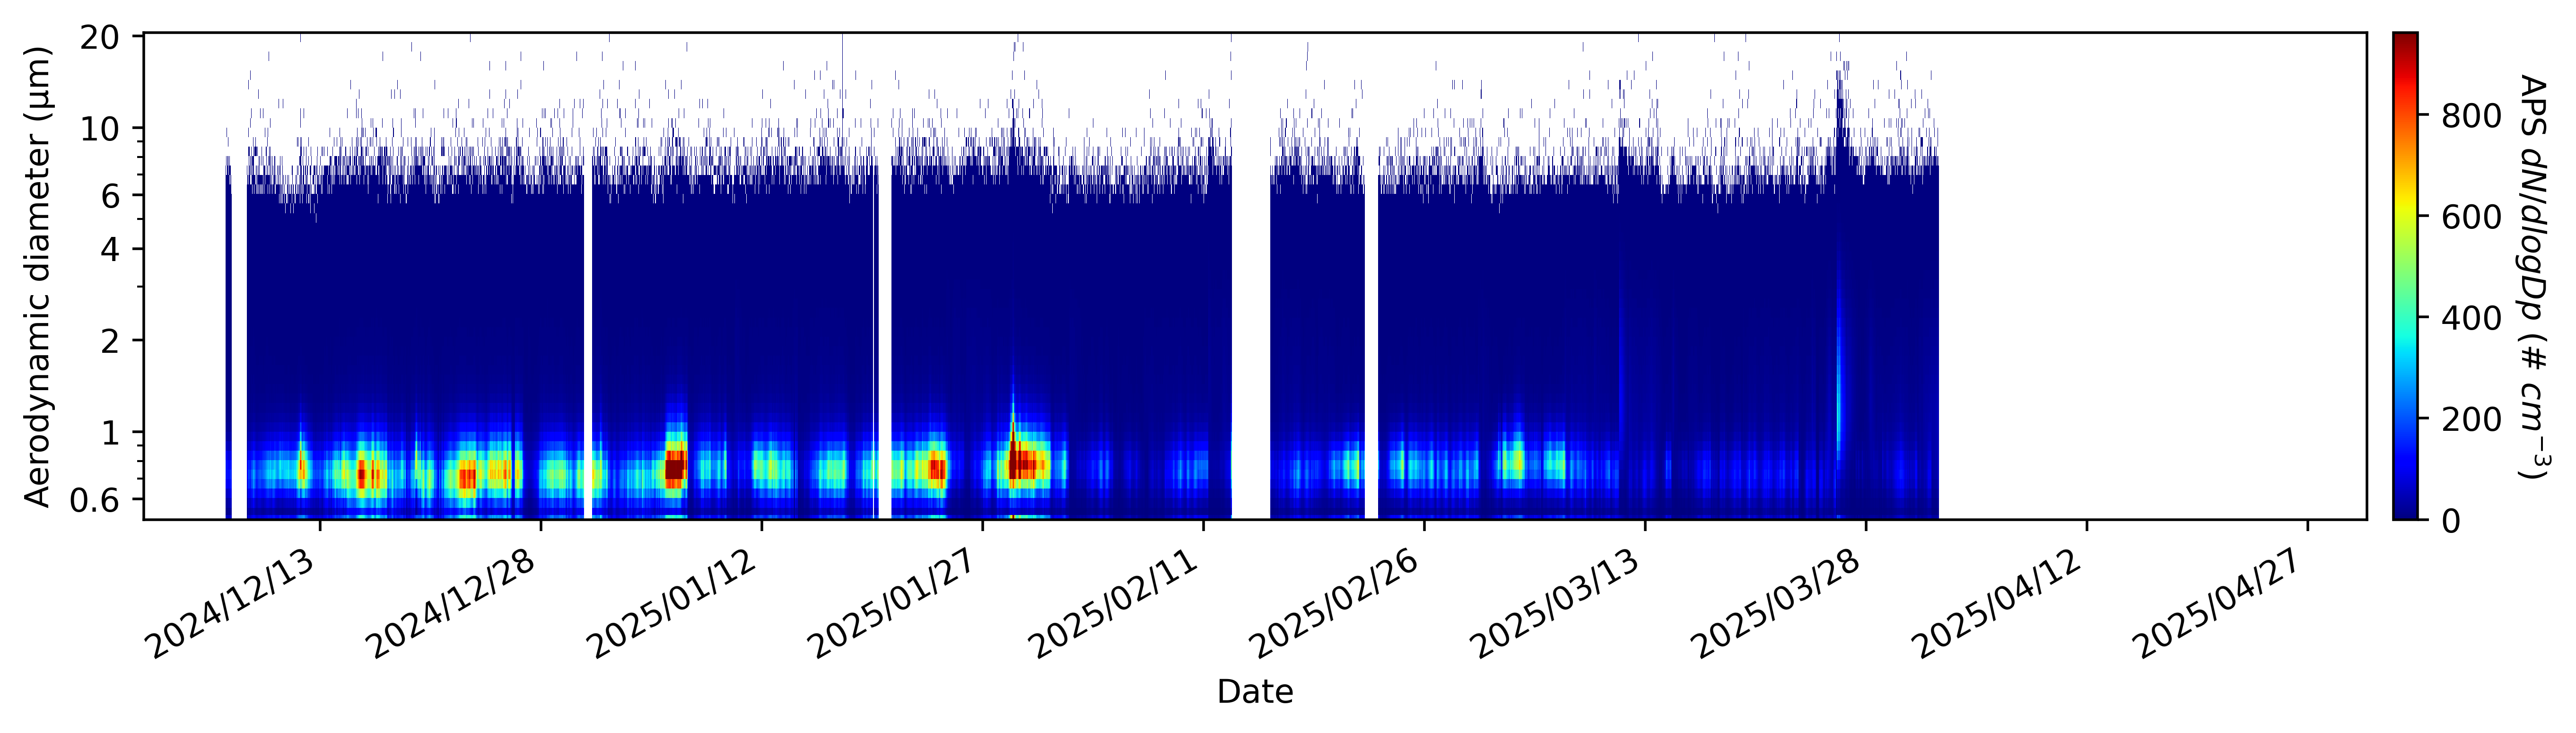

In [ ]:
# 4. 绘制时间序列图
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

upper_bound = 99.9 # 颜色上限的分位数

# 1) 准备矩阵：dN (bin, time)
t = m.index
dN = m.to_numpy().T  # (bin, time)

# 2) 计算 x/y edges
t_num = mdates.date2num(t.to_pydatetime())
dt_day = dt_sec / 86400.0
x_edges = np.r_[t_num[0] - 0.5*dt_day,
                0.5*(t_num[:-1] + t_num[1:]),
                t_num[-1] + 0.5*dt_day]

y_edges = np.empty(len(Dp) + 1)
y_edges[1:-1] = np.sqrt(Dp[:-1] * Dp[1:])
y_edges[0] = Dp[0]**2 / y_edges[1]
y_edges[-1] = Dp[-1]**2 / y_edges[-2]

# 3) Z = dN（线性），<=0 或 NaN 变为 NaN
Z = np.where(dN > 0, dN, np.nan)

# 4) 作图（缺测显示白色）
fig, ax = plt.subplots(figsize=(12, 3.2), dpi=500)

cmap = plt.colormaps["jet"].copy()
cmap.set_bad("white")

vmin = 0
vmax = np.nanpercentile(Z, upper_bound)
Z = np.ma.masked_invalid(Z) # 这一行需要放在 vmax (分位数)计算之后
pcm = ax.pcolormesh(x_edges, y_edges, Z, shading="auto",
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax
                    )

ax.set_yscale("log")
ax.set_ylabel("Aerodynamic diameter (µm)")
ax.set_xlabel("Date")

# y 刻度
yticks = [0.6, 1, 2, 4, 6, 10, 20]
ax.set_yticks(yticks)
ax.set_yticklabels([str(v) for v in yticks])

# x 轴
ax.set_xlim(pd.Timestamp('2024-12-01'), pd.Timestamp('2025-05-01'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y/%m/%d"))
fig.autofmt_xdate()# 自动旋转日期标签
#locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
#ax.xaxis.set_major_locator(locator)
#ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

# ax.set_xlim(pd.Timestamp('2024-12-08'), pd.Timestamp('2024-12-14')) # 如果你想限制显示某几天，可以取消注释这一行

# 子图标记
#ax.text(0.01, 0.96, "f", transform=ax.transAxes,
#        ha="left", va="top", fontweight="bold")

cbar = fig.colorbar(pcm, ax=ax, pad=0.01)
cbar.set_label("APS $dN/dlogDp$ (# $cm^{-3}$)", rotation=270, labelpad=15)
#cbar.set_ticks([0, 0.5, 1, 1.5, 2, 2.5])

plt.tight_layout()
#plt.show()
plt.savefig(r"C:\Users\admin\Desktop\temp\2.png", dpi=500)


### 25/03/26 00:00 数值突变: 分析原因

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

win = m.loc["2025-03-25 18:00":"2025-03-26 06:00"]
fig, ax = plt.subplots(dpi=160)
for col in ["0.723", "1.037", "2.129"]:
    y = win[col]
    logy = np.log10(y.where(y > 0))
    ax.plot(win.index, logy, marker=".", linewidth=0.8, label=col+" µm")
ax.axvline(pd.Timestamp("2025-03-26"), linestyle="--")
ax.legend()
ax.set_ylabel("$log_{10}(dN)$")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%y/%m/%d %H:%M"))
fig.autofmt_xdate()# 自动旋转日期标签
#plt.tight_layout()
plt.show()


In [ ]:
raw = merged.set_index("__dt__").sort_index()
raw_win = raw.loc["2025-03-25 18:00":"2025-03-26 06:00"]

plt.figure(figsize=(10,3), dpi=150)
plt.plot(raw_win.index, np.log10(raw_win["1.037"].where(raw_win["1.037"]>0)), ".", markersize=2)
plt.axvline(pd.Timestamp("2025-03-26"), linestyle="--")
plt.ylabel("raw log10(dN) at 1.037 µm")
plt.tight_layout()
plt.show()
